## Model Pipeline Training
### Baseline Model vs Resnet

ResNet with fine-tuning is outperforming the baseline (~85% vs ~75% val accuracy), less overfitting due to pretrained features + dropout, transfer learning seems to be working well for this small batched datasets.

In [2]:
# External Imports
import sys
from pathlib import Path
import glob
import torch
import torch.optim as optim
import torch.nn as nn
from torchinfo import summary

# Internal Imports
sys.path.insert(0, '../src')
from src.DataIntegrity import data_integrity_check
from src.Dataset import split_patients, get_dataloaders
from src.Model import BaselineModel, build_resnet, fit, plot_loss_acc, save_weights

In [3]:
data_path = Path("../data/raw/lgg-mri-segmentation/kaggle_3m")
rejected_path = Path("../data/processed/data-integrity")

In [ ]:
accepted_data, rejected_data = data_integrity_check(data_path)

[INFO] Data Integrity Checks:  14%|█▍        | 16/112 [21:09<1:56:15, 72.66s/it]

In [4]:
SPLIT_SEED = 42
train_patients, val_patients, test_patients = split_patients(accepted_data, seed=SPLIT_SEED)

[INFO]  Splitting dataset with seed 42...
[INFO]  Train Set: 76  | Tumor Ratio: 0.352
[INFO]  Valid Set: 17  | Tumor Ratio: 0.360
[INFO]  Test Set:  17  | Tumor Ratio: 0.372


In [5]:
BATCH_SIZE = 32
train_dataloader, val_dataloader, test_dataloader = get_dataloaders(train_patients, val_patients, test_patients, batch_size=BATCH_SIZE)

In [6]:
baseline_model = BaselineModel()
device = "cuda" if torch.cuda.is_available() else "cpu"
baseline_model.to(device)

BaselineModel(
  (layer1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(2, 2), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(2, 2), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Flatten(start_dim=1, end_dim=-1)
  (layer4): Sequential(
    (0): Linear(in_features=96800, out_features=256, bias=True)
    (1): ReLU()
  )
  (layer5): Linear(in_features=256, out_features=2, bias=True)
)

In [7]:
baseline_epoch_data = fit(
    model = baseline_model,
    train_data = train_dataloader,
    valid_data = val_dataloader,
    optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3),
    loss_fn = nn.CrossEntropyLoss(),
    device = device,
    epochs=15,
    patience=5
)

Epoch [1/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.7394 | 0.5935 Accuracy: 0.7105 | 0.6998
Epoch [2/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.4953 | 0.5886 Accuracy: 0.7450 | 0.6788
Epoch [3/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.4768 | 0.5081 Accuracy: 0.7795 | 0.6902
Epoch [4/15 <0:00:17><0/5>] Loss [Train | Validation]: 0.4255 | 0.5485 Accuracy: 0.7924 | 0.7438
Epoch [5/15 <0:00:17><1/5>] Loss [Train | Validation]: 0.3994 | 0.5387 Accuracy: 0.8060 | 0.7342
Epoch [6/15 <0:00:17><2/5>] Loss [Train | Validation]: 0.3843 | 0.5286 Accuracy: 0.8222 | 0.7438
Epoch [7/15 <0:00:17><3/5>] Loss [Train | Validation]: 0.3721 | 0.5576 Accuracy: 0.8297 | 0.7400
Epoch [8/15 <0:00:17><4/5>] Loss [Train | Validation]: 0.3644 | 0.6101 Accuracy: 0.8434 | 0.7361
[INFO] Patience reached, best epoch was 3 with 0.5081 validation loss.


In [8]:
resnet_model = build_resnet(num_classes=2)
resnet_model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
resnet_epoch_data = fit(
    model = resnet_model,
    train_data = train_dataloader,
    valid_data = val_dataloader,
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=1e-3),
    loss_fn = nn.CrossEntropyLoss(),
    device = device,
    epochs=15,
    patience=5
)

In [ ]:
# Unfreeze Resnet layers and continue training
# Freeze everything
for param in resnet_model.parameters():
  param.requires_grad = False

# Replace fc (automatically unfrozen)
resnet_model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features=512, out_features=2)
)
# Unfreeze layer4
for param in resnet_model.layer4.parameters():
  param.requires_grad = True

resnet_model.to(device)

In [ ]:
resnet_epoch_data = fit(
    model = resnet_model,
    train_data = train_dataloader,
    valid_data = val_dataloader,
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=1e-4),
    loss_fn = nn.CrossEntropyLoss(),
    device = device,
    epochs=15,
    patience=5
)

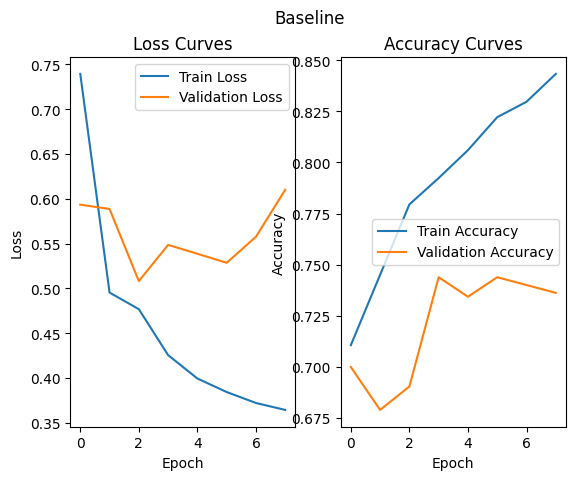

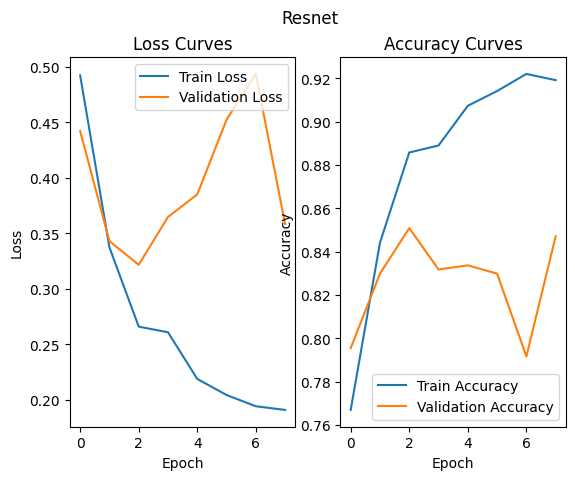

In [13]:
plot_loss_acc(baseline_epoch_data, "Baseline")
plot_loss_acc(resnet_epoch_data, "Resnet")

In [ ]:
save_weights("resnet18", resnet_model, Path("../models"))